# Loan Amount Recommendation — Dataset Summary

## About the Dataset

This dataset contains 15,000 records of borrower financial profiles designed for predicting a recommended loan amount. It covers a range of personal, employment, and credit attributes commonly used in retail lending decisions. The dataset includes realistic data quality issues such as missing values and outliers to reflect real-world conditions.

| Property | Value |
|---|---|
| Rows | 15,000 |
| Columns | 17 |
| Domain | Finance |
| Problem Type | Regression |
| Target Variable | `recommended_loan_amount` |

---

## Column Descriptions

| Column | Type | Description |
|---|---|---|
| `age` | int | Age of the borrower in years |
| `years_employed` | int | Number of years the borrower has been employed |
| `annual_income` | float | Borrower's gross annual income in USD |
| `credit_score` | int | Borrower's credit score (300–850) |
| `dti_ratio` | float | Debt-to-income ratio |
| `existing_debt` | float | Total existing debt outstanding in USD |
| `loan_purpose` | categorical | The stated purpose of the loan (e.g. home_purchase, auto, education) |
| `employment_type` | categorical | Nature of employment (salaried, self_employed, contract, part_time) |
| `monthly_expenses` | float | Borrower's estimated monthly expenses in USD |
| `num_dependents` | int | Number of financial dependents |
| `savings_balance` | float | Total savings balance in USD |
| `num_open_credit_lines` | int | Number of currently open credit lines |
| `num_previous_defaults` | int | Number of previous loan defaults |
| `property_owned` | binary | Whether the borrower owns property (1 = yes, 0 = no) |
| `loan_term_months` | int | Requested loan repayment term in months |
| `market_rate` | float | Prevailing market interest rate at time of application |
| `recommended_loan_amount` | float | **Target** — the recommended loan amount in USD |


## ML Lifecycle

1. Business Problem ↓
2. Data Collection ↓
3. Data Preparation ↓
4. Feature Engineering ↓
5. Model Selection & Training ↓
6. Model Evaluation ↓
7. Deployment ↓
9. Monitoring & Maintenance ↓
10. Retraining

In [55]:
# Core Data Science Libraries
import pandas as pd
import numpy as np
from pandasql import sqldf
import warnings
warnings.filterwarnings('ignore')

# Visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

# Model Selection and Evaluation
from sklearn.model_selection import (train_test_split, GridSearchCV, 
                                      RandomizedSearchCV, cross_val_score, 
                                      KFold, learning_curve)
from sklearn.metrics import (mean_squared_error, mean_absolute_error, 
                             r2_score, mean_absolute_percentage_error)
import shap

# Bayesian Optimization
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# Statistical Testing
from scipy import stats
from scipy.stats import shapiro, normaltest, anderson
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.api import OLS, add_constant
import statsmodels.api as sm
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Model Persistence
import pickle
import joblib

# Utilities
from datetime import datetime
import os

print("All libraries imported successfully!")
print(f"XGBoost Version: {XGBRegressor.__module__}")
print(f"Scikit-learn Version: {sm.__version__}")

All libraries imported successfully!
XGBoost Version: xgboost.sklearn
Scikit-learn Version: 0.14.6


In [2]:
# To run the SQL Queries
pysqldf = lambda q: sqldf(q, globals())
# Load the dataset
df = pd.read_csv('loan_amount_dataset.csv')

In [74]:
df.isnull().sum()

age                           0
years_employed                0
annual_income                 0
credit_score                  0
dti_ratio                     0
existing_debt              1500
loan_purpose                  0
employment_type               0
monthly_expenses              0
num_dependents                0
savings_balance             750
num_open_credit_lines         0
num_previous_defaults         0
property_owned                0
loan_term_months              0
market_rate                   0
recommended_loan_amount       0
loan_purpose_encoded          0
employment_type_encoded       0
dtype: int64

In [75]:

query = """select age, years_employed, annual_income, savings_balance from df where savings_balance >= annual_income order by savings_balance desc -- Got 3661 rows one outlier 800000.00 amount is used for many columns"""

result = pysqldf(query)
print(result.head())

   age  years_employed  annual_income  savings_balance
0   34              14      263669.47         800000.0
1   44              17      244444.55         800000.0
2   35               4      143367.91         800000.0
3   37              12      165320.72         800000.0
4   40              12      187483.96         800000.0


In [49]:
# Writing queries to analyze the data 
# select * from df where age <= years_employed -- it was null, meaning data is pretty consistent
# select * from df where existing_debt is null -- 1500 people don't have any previous loans
# select age, years_employed, annual_income, savings_balance from df where savings_balance >= annual_income order by savings_balance desc -- Got 3661 rows one outlier 800000.00 amount is used for many columns
# select * from df where savings_balance = 800000.00 -- 6 rows need a better formula to impute the savings_balance column for these rows

# select years_employed, annual_income, savings_balance/annual_income as original_ratio, savings_balance, rk from (
# select years_employed, annual_income, savings_balance, dense_rank() over(partition by years_employed order by savings_balance desc, annual_income desc) rk from df) t where years_employed in (4, 6, 12, 14, 17, 20) and rk in (1,2, 3)
query = """
WITH ranked AS (
    SELECT
        years_employed,
        annual_income,
        savings_balance,
        savings_balance / annual_income AS original_ratio,
        DENSE_RANK() OVER (
            PARTITION BY years_employed
            ORDER BY savings_balance DESC, annual_income DESC
        ) AS rk
    FROM df
),
ratios AS (
    SELECT
        years_employed,
        original_ratio AS replacement_ratio
    FROM ranked
    WHERE rk = 2
)
SELECT
    r.years_employed,
    r.annual_income,
    CASE
        WHEN r.savings_balance = 800000
            THEN round(r.annual_income * rt.replacement_ratio,2)
        ELSE round(r.savings_balance,2)
    END AS new_savings_balance,
    r.rk
    ,r.savings_balance
FROM ranked r
LEFT JOIN ratios rt
    ON r.years_employed = rt.years_employed
WHERE r.years_employed IN (4,6,12,14,17,20)
  AND r.rk IN (1,2,3);
"""

result = pysqldf(query)
print(result.head())

   years_employed  annual_income  new_savings_balance  rk  savings_balance
0               4      143367.91            688118.62   1        800000.00
1               4      100964.44            484595.97   2        484595.97
2               4      124775.52            323994.86   3        323994.86
3               6      126353.20            502685.75   1        800000.00
4               6      116376.81            462995.51   2        462995.51


In [5]:
df2 = df.copy()

df2['rk'] = (
    df2.sort_values(['years_employed', 'savings_balance', 'annual_income'],
                    ascending=[True, False, False])
       .groupby('years_employed')
       .cumcount() + 1
)

df2['original_ratio'] = (
    df2['savings_balance'] / df2['annual_income']
)

replacement_ratio = (
    df2[df2['rk'] == 2]
      .set_index('years_employed')['original_ratio']
)

mask = df2['savings_balance'] == 800000

df2.loc[mask, 'savings_balance'] = (
    df2.loc[mask, 'annual_income'] *
    df2.loc[mask, 'years_employed'].map(replacement_ratio)
).round(2)
df2.head()

,age,years_employed,annual_income,credit_score,dti_ratio,existing_debt,loan_purpose,employment_type,monthly_expenses,num_dependents,savings_balance,num_open_credit_lines,num_previous_defaults,property_owned,loan_term_months,market_rate,recommended_loan_amount,rk,original_ratio
0,44,21,111847.46,626,0.3202,NaN,home_purchase,salaried,5482.05,2,128214.10,7,0,1,120,6.978,73744.17,50,1.146330
1,38,15,44789.71,637,0.2477,10795.74,personal,salaried,1183.80,0,11082.77,3,0,0,60,6.478,28612.28,488,0.247440
2,46,24,120535.77,624,0.2443,34350.27,home_purchase,self_employed,4304.42,3,50514.25,6,0,1,84,7.248,71414.88,167,0.419081
3,55,36,26826.55,662,0.2992,8484.04,auto,contract,824.15,1,6641.62,0,0,0,48,5.904,26179.55,93,0.247576
4,37,12,101526.65,618,0.1400,NaN,business,salaried,3720.98,1,66202.58,5,0,1,48,6.570,59251.02,157,0.652071


In [6]:
# select age, years_employed, annual_income, savings_balance, dense_rank() over (partition by age order by age, years_employed, savings_balance, annual_income) as rk from df2 where age not in (22, 23)
query = """
select age, annual_income from df2 where years_employed = 0 order by age, annual_income desc
"""

result = pysqldf(query)
print(result.head(5))

   age  annual_income
0   22     9140545.12
1   22     7628642.07
2   22     7261709.47
3   22     6970818.35
4   22     6963211.03


In [7]:
df3 = df2
df3['experience_group'] = df3['years_employed'].apply(
    lambda x: '0 years' if x == 0 else '1+ years'
)
df3.head()

,age,years_employed,annual_income,credit_score,dti_ratio,existing_debt,loan_purpose,employment_type,monthly_expenses,num_dependents,savings_balance,num_open_credit_lines,num_previous_defaults,property_owned,loan_term_months,market_rate,recommended_loan_amount,rk,original_ratio,experience_group
0,44,21,111847.46,626,0.3202,NaN,home_purchase,salaried,5482.05,2,128214.10,7,0,1,120,6.978,73744.17,50,1.146330,1+ years
1,38,15,44789.71,637,0.2477,10795.74,personal,salaried,1183.80,0,11082.77,3,0,0,60,6.478,28612.28,488,0.247440,1+ years
2,46,24,120535.77,624,0.2443,34350.27,home_purchase,self_employed,4304.42,3,50514.25,6,0,1,84,7.248,71414.88,167,0.419081,1+ years
3,55,36,26826.55,662,0.2992,8484.04,auto,contract,824.15,1,6641.62,0,0,0,48,5.904,26179.55,93,0.247576,1+ years
4,37,12,101526.65,618,0.1400,NaN,business,salaried,3720.98,1,66202.58,5,0,1,48,6.570,59251.02,157,0.652071,1+ years


In [8]:

fig = px.scatter(
    df3,
    x='age',
    y='annual_income',
    color='experience_group',
    title='Annual Income by Age',
    labels={
        'age': 'Age',
        'annual_income': 'Annual Income'
    }
)

fig.show()

In [9]:
query = """
select age, avg(rt) from (
select age, annual_income, savings_balance, savings_balance/annual_income rt 
from df3 where savings_balance is not null and experience_group = '1+ years' order by age, savings_balance, annual_income desc) t
group by age
"""

result = pysqldf(query)
print(result.head())

   age   avg(rt)
0   22  0.805401
1   23  0.810957
2   24  0.784826
3   25  0.880249
4   26  0.882632


In [10]:
age_ratio = (
    df3.loc[
        (df3['savings_balance'].notnull()) &
        (df3['experience_group'] == '1+ years')
    ]
    .assign(rt=lambda x: x['savings_balance'] / x['annual_income'])
    .groupby('age')['rt']
    .median()
)
mask = df3['savings_balance'].isnull()
df3.loc[mask, 'savings_balance'] = (
    df3.loc[mask, 'annual_income'] *
    df3.loc[mask, 'age'].map(age_ratio)
).round(2)
print(df3['savings_balance'].isnull().sum())

0


In [11]:
df4 = df3 
df4["existing_debt"] = df4["existing_debt"].fillna(0)
df4.isnull().sum()

age                          0
years_employed               0
annual_income                0
credit_score                 0
dti_ratio                    0
existing_debt                0
loan_purpose                 0
employment_type              0
monthly_expenses             0
num_dependents               0
savings_balance              0
num_open_credit_lines        0
num_previous_defaults        0
property_owned               0
loan_term_months             0
market_rate                  0
recommended_loan_amount      0
rk                           0
original_ratio             750
experience_group             0
dtype: int64

In [12]:
df5 = df4
df5 = df5.drop(columns=df5.loc[:, 'rk':'experience_group'].columns)
df5.isnull().sum()

age                        0
years_employed             0
annual_income              0
credit_score               0
dti_ratio                  0
existing_debt              0
loan_purpose               0
employment_type            0
monthly_expenses           0
num_dependents             0
savings_balance            0
num_open_credit_lines      0
num_previous_defaults      0
property_owned             0
loan_term_months           0
market_rate                0
recommended_loan_amount    0
dtype: int64

In [15]:
# Cleaned dataframe with original columns now 
# Now label encoding
le = LabelEncoder()

df5['loan_purpose_encoded'] = le.fit_transform(df5['loan_purpose'])
df5['employment_type_encoded'] = le.fit_transform(df5['employment_type'])

df5 = df5.drop(columns=['loan_purpose', 'employment_type'])
df5 = df5.rename(columns={'loan_purpose_encoded':'loan_purpose', 'employment_type_encoded': 'employment_type'})
df5.head()


,age,years_employed,annual_income,credit_score,dti_ratio,existing_debt,monthly_expenses,num_dependents,savings_balance,num_open_credit_lines,num_previous_defaults,property_owned,loan_term_months,market_rate,recommended_loan_amount,loan_purpose,employment_type
0,44,21,111847.46,626,0.3202,0.00,5482.05,2,128214.10,7,0,1,120,6.978,73744.17,3,2
1,38,15,44789.71,637,0.2477,10795.74,1183.80,0,11082.77,3,0,0,60,6.478,28612.28,5,2
2,46,24,120535.77,624,0.2443,34350.27,4304.42,3,50514.25,6,0,1,84,7.248,71414.88,3,3
3,55,36,26826.55,662,0.2992,8484.04,824.15,1,6641.62,0,0,0,48,5.904,26179.55,0,0
4,37,12,101526.65,618,0.1400,0.00,3720.98,1,66202.58,5,0,1,48,6.570,59251.02,1,2


In [50]:
# Correlation plot
df_corr = df.corr(numeric_only=True)
df5_corr = df5.corr()
fig1 = px.imshow(
    df_corr,
    text_auto='.1f',
    color_continuous_scale='RdBu_r'
)

fig2 = px.imshow(
    df5_corr,
    text_auto='.1f',
    color_continuous_scale='RdBu_r'
)
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Original Data Correlation",
        "Cleaned Data Correlation"
    )
)

fig.add_trace(fig1.data[0], row=1, col=1)
fig.add_trace(fig2.data[0], row=1, col=2)

fig.update_layout(
    height=800,
    width=2200,
    title_text="Correlation Matrices"
)

fig.show()

In [17]:
corr = df5.corr(numeric_only=True)
print(corr['recommended_loan_amount'].sort_values(ascending=False))

recommended_loan_amount    1.000000
annual_income              0.711428
monthly_expenses           0.575230
existing_debt              0.466089
credit_score               0.350793
savings_balance            0.325953
age                        0.154327
years_employed             0.139922
property_owned             0.102824
num_open_credit_lines      0.049868
employment_type            0.004799
market_rate                0.004364
num_dependents             0.000876
loan_purpose              -0.000907
loan_term_months          -0.008301
num_previous_defaults     -0.026383
dti_ratio                 -0.148144
Name: recommended_loan_amount, dtype: float64


In [18]:
fig1 = px.scatter(
    df,
    x='annual_income',
    y='savings_balance',
    color='years_employed',
    hover_data=['age', 'credit_score']
)

fig2 = px.scatter(
    df5,
    x='annual_income',
    y='savings_balance',
    color='years_employed',
    hover_data=['age', 'credit_score']
)
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        "Original Savings vs Income",
        "Cleaned Savings vs Income"
    ]
)

for trace in fig1.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig2.data:
    fig.add_trace(trace, row=1, col=2)
fig.update_xaxes(title_text="Annual Income", row=1, col=1)
fig.update_yaxes(title_text="Savings Balance", row=1, col=1)

fig.update_xaxes(title_text="Annual Income", row=1, col=2)
fig.update_yaxes(title_text="Savings Balance", row=1, col=2)

fig.update_layout(
    title="Savings vs Income: Original vs Cleaned",
    width=1600,
    height=700
)

fig.show()

In [19]:
fig = px.scatter(
    df5,
    x='annual_income',
    y='recommended_loan_amount',
    color='credit_score',
    title='Recommended Loan Amount vs Income'
)

fig.show()

In [20]:
fig1 = px.box(
    df,
    x='age',
    y='savings_balance'
)

fig2 = px.box(
    df5,
    x='age',
    y='savings_balance'
)

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Original Savings Distribution by Age",
        "Cleaned Savings Distribution by Age"
    )
)

for trace in fig1.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig2.data:
    fig.add_trace(trace, row=1, col=2)

fig.update_xaxes(title_text="Age", row=1, col=1)
fig.update_yaxes(title_text="Savings Balance", row=1, col=1)

fig.update_xaxes(title_text="Age", row=1, col=2)
fig.update_yaxes(title_text="Savings Balance", row=1, col=2)

fig.update_layout(
    title="Savings Distribution by Age: Original vs Cleaned",
    width=1600,
    height=700,
    showlegend=False
)

fig.show()

In [21]:
fig1 = px.scatter(
    df,
    x='years_employed',
    y='savings_balance'
)

fig2 = px.scatter(
    df5,
    x='years_employed',
    y='savings_balance'
)

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Original Savings Distribution by years employed",
        "Cleaned Savings Distribution by years employed"
    )
)

for trace in fig1.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig2.data:
    fig.add_trace(trace, row=1, col=2)

fig.update_xaxes(title_text="Years Employed", row=1, col=1)
fig.update_yaxes(title_text="Savings Balance", row=1, col=1)

fig.update_xaxes(title_text="Years Employed", row=1, col=2)
fig.update_yaxes(title_text="Savings Balance", row=1, col=2)

fig.update_layout(
    title="Savings Distribution by Years Employed: Original vs Cleaned",
    width=1600,
    height=700,
    showlegend=False
)

fig.show()

In [22]:
fig1 = px.scatter(
    df,
    x='years_employed',
    y='annual_income'
)

fig2 = px.scatter(
    df5,
    x='years_employed',
    y='annual_income'
)

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Original annual income Distribution by years employed",
        "Cleaned annual income Distribution by years employed"
    )
)

for trace in fig1.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig2.data:
    fig.add_trace(trace, row=1, col=2)

fig.update_xaxes(title_text="Years Employed", row=1, col=1)
fig.update_yaxes(title_text="Annual Income", row=1, col=1)

fig.update_xaxes(title_text="Years Employed", row=1, col=2)
fig.update_yaxes(title_text="Annual Income", row=1, col=2)

fig.update_layout(
    title="Annual Income Distribution by Years Employed: Original vs Cleaned",
    width=1600,
    height=700,
    showlegend=False
)

fig.show()

In [23]:
fig = px.histogram(
    df5,
    x='credit_score',
    nbins=30,
    title='Credit Score Distribution'
)

fig.show()

In [24]:
fig = px.scatter(
    df5,
    x='dti_ratio',
    y='recommended_loan_amount',
    color='credit_score',
    title='DTI Ratio vs Recommended Loan Amount'
)

fig.show()

In [25]:
fig = px.box(
    df,
    x='employment_type',
    y='recommended_loan_amount',
    title='Loan Amount by Employment Type'
)

fig.show()

In [29]:
# With zero-collinear columns
X = df5.drop(columns=['recommended_loan_amount'])
y = df5['recommended_loan_amount'] 

# Split 1: 70-30 (test, validation)
X_train_70, X_test_val, y_train_70, y_test_val = train_test_split(
    X, y, test_size=0.30, random_state=42
)
# Step 2: split temp into 50-50 => 15% test, 15% validation
X_test, X_val, y_test, y_val = train_test_split(
    X_test_val, y_test_val, test_size=0.50, random_state=42
)
# Pipeline 1
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
linear_pipeline.fit(X_train_70, y_train_70)
y_val_pred_linear_pipeline = linear_pipeline.predict(X_val)

# Pipeline 2
rf_model = RandomForestRegressor(random_state=42)
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
rf_model.fit(X_train_70, y_train_70)
xgb_model.fit(X_train_70, y_train_70)
pred_rf = rf_model.predict(X_val)
pred_xgb = xgb_model.predict(X_val)

results = pd.DataFrame({
    "Model": ["Linear", "Random Forest", "XGBoost"],
    "R2": [
        r2_score(y_val, y_val_pred_linear_pipeline),
        r2_score(y_val, pred_rf),
        r2_score(y_val, pred_xgb)
    ],
    "MAE": [
        mean_absolute_error(y_val, y_val_pred_linear_pipeline),
        mean_absolute_error(y_val, pred_rf),
        mean_absolute_error(y_val, pred_xgb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_val, y_val_pred_linear_pipeline)),
        np.sqrt(mean_squared_error(y_val, pred_rf)),
        np.sqrt(mean_squared_error(y_val, pred_xgb))
    ]
})

results = results.sort_values("R2", ascending=False)
results

,Model,R2,MAE,RMSE
1,Random Forest,0.997048,1096.701912,1889.575690
2,XGBoost,0.996281,797.990444,2121.060679
0,Linear,0.855155,6750.662408,13236.704568


In [36]:
X = df5.drop(columns=['recommended_loan_amount', 'employment_type',
    'market_rate',
    'num_dependents',
    'loan_purpose'])
y = df5['recommended_loan_amount'] 

# Split 1: 70-30 (test, validation)
X_train_70, X_test_val, y_train_70, y_test_val = train_test_split(
    X, y, test_size=0.30, random_state=42
)
# Step 2: split temp into 50-50 => 15% test, 15% validation
X_test, X_val, y_test, y_val = train_test_split(
    X_test_val, y_test_val, test_size=0.50, random_state=42
)
# Pipeline 1
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
linear_pipeline.fit(X_train_70, y_train_70)
y_val_pred_linear_pipeline = linear_pipeline.predict(X_val)
# Pipeline 2
rf_model = RandomForestRegressor(random_state=42)
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
rf_model.fit(X_train_70, y_train_70)
xgb_model.fit(X_train_70, y_train_70)
pred_rf = rf_model.predict(X_val)
pred_xgb = xgb_model.predict(X_val)
results = pd.DataFrame({
    "Model": ["Linear", "Random Forest", "XGBoost"],
    "R2": [
        r2_score(y_val, y_val_pred_linear_pipeline),
        r2_score(y_val, pred_rf),
        r2_score(y_val, pred_xgb)
    ],
    "MAE": [
        mean_absolute_error(y_val, y_val_pred_linear_pipeline),
        mean_absolute_error(y_val, pred_rf),
        mean_absolute_error(y_val, pred_xgb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_val, y_val_pred_linear_pipeline)),
        np.sqrt(mean_squared_error(y_val, pred_rf)),
        np.sqrt(mean_squared_error(y_val, pred_xgb))
    ]
})

results = results.sort_values("R2", ascending=False)
results

,Model,R2,MAE,RMSE
1,Random Forest,0.99712,1073.477279,1866.436942
2,XGBoost,0.99686,787.460940,1948.936430
0,Linear,0.85524,6745.099558,13232.830345


In [ ]:
le = LabelEncoder()

df6 = df.copy()

df6['loan_purpose_encoded'] = le.fit_transform(df6['loan_purpose'])
df6['employment_type_encoded'] = le.fit_transform(df6['employment_type'])

df6 = df6.drop(columns=['loan_purpose', 'employment_type'])

df6 = df6.rename(columns={
    'loan_purpose_encoded': 'loan_purpose',
    'employment_type_encoded': 'employment_type'
})

# Features and target
X = df6.drop(columns=[
    'recommended_loan_amount',
    'employment_type',
    'market_rate',
    'num_dependents',
    'loan_purpose'
])

y = df6['recommended_loan_amount']

# ==========================
# Train/Test Split
# ==========================

X_train_70, X_test_val, y_train_70, y_test_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# ==========================
# MICE Imputation
# ==========================

mice = IterativeImputer(random_state=42)

df_mice = pd.DataFrame(
    mice.fit_transform(X_train_70),
    columns=X_train_70.columns,
    index=X_train_70.index
)

# ==========================
# Prepare df5 dataset
# ==========================

X_df5 = df5.drop(columns=[
    'recommended_loan_amount',
    'employment_type',
    'market_rate',
    'num_dependents',
    'loan_purpose'
])

y_df5 = df5['recommended_loan_amount']

X_train_70_df5, X_test_val_df5, y_train_70_df5, y_test_val_df5 = train_test_split(
    X_df5,
    y_df5,
    test_size=0.30,
    random_state=42
)

# Ensure row alignment
X_train_70_df5 = X_train_70_df5.loc[df_mice.index]

# ==========================
# Compare only imputed values
# ==========================

missing_mask = X_train_70.isna()

comparisons = []

for col in X_train_70.columns:

    missing_rows = X_train_70.index[
        missing_mask[col]
    ]

    for idx in missing_rows:

        comparisons.append({
            "row": idx,
            "column": col,
            "MICE_value": df_mice.loc[idx, col],
            "Other_value": X_train_70_df5.loc[idx, col],
            "Difference": (
                df_mice.loc[idx, col]
                - X_train_70_df5.loc[idx, col]
            )
        })

comparison_df = pd.DataFrame(comparisons)

# ==========================
# Summary Statistics
# ==========================

comparison_df["Abs_Difference"] = (
    comparison_df["Difference"].abs()
)

summary_df = (
    comparison_df.groupby("column")
    .agg(
        Num_Imputed=("column", "size"),
        Mean_Abs_Diff=("Abs_Difference", "mean"),
        Max_Abs_Diff=("Abs_Difference", "max")
    )
    .reset_index()
)

# ==========================
# Results
# ==========================

print("Comparison of imputed values:")
print(comparison_df[comparison_df['column']=='savings_balance'].head(10))

print("\nSummary:")
print(summary_df)

Comparison of imputed values:
        row           column    MICE_value  Other_value    Difference  \
1067   1896  savings_balance  43654.555996     26225.11  17429.445996   
1068   9751  savings_balance  55272.267702     55380.28   -108.012298   
1069   5418  savings_balance  40246.283424     28764.81  11481.473424   
1070   8310  savings_balance  60130.909441     38347.74  21783.169441   
1071   3614  savings_balance  48583.815886     28554.35  20029.465886   
1072   8248  savings_balance  17017.077698     10833.21   6183.867698   
1073   5653  savings_balance  35638.802778     27997.84   7640.962778   
1074   3219  savings_balance  41338.324146     25543.22  15795.104146   
1075   1193  savings_balance  27038.260270     17012.34  10025.920270   
1076  12799  savings_balance  39376.515510     27463.23  11913.285510   

      Abs_Difference  
1067    17429.445996  
1068      108.012298  
1069    11481.473424  
1070    21783.169441  
1071    20029.465886  
1072     6183.867698  
1073 

In [67]:
selected_rows = df.loc[comparison_df['row'].unique()].copy()

selected_rows['row'] = selected_rows.index

result = comparison_df.merge(
    selected_rows,
    on='row',
    how='left'
)
result[result['column']=='savings_balance'].head()

,row,column,MICE_value,Other_value,Difference,Abs_Difference,age,years_employed,annual_income,credit_score,...,num_dependents,savings_balance,num_open_credit_lines,num_previous_defaults,property_owned,loan_term_months,market_rate,recommended_loan_amount,loan_purpose_encoded,employment_type_encoded
1067,1896,savings_balance,43654.555996,26225.11,17429.445996,17429.445996,37,18,41102.63,644,...,4,NaN,6,0,1,180,7.766,31502.16,3,3
1068,9751,savings_balance,55272.267702,55380.28,-108.012298,108.012298,41,15,95817.27,658,...,3,NaN,2,0,1,36,7.638,54808.71,4,2
1069,5418,savings_balance,40246.283424,28764.81,11481.473424,11481.473424,34,6,50326.54,532,...,0,NaN,5,0,1,60,6.982,30947.97,6,2
1070,8310,savings_balance,60130.909441,38347.74,21783.169441,21783.169441,30,6,63884.32,598,...,3,NaN,4,1,1,36,5.631,39252.93,1,2
1071,3614,savings_balance,48583.815886,28554.35,20029.465886,20029.465886,46,22,48229.03,597,...,0,NaN,4,0,1,48,6.749,36177.66,3,2


In [73]:
result["MICE_ratio"] = (
    result["MICE_value"] /
    result["annual_income"]
)
result["Other_ratio"] = (
    result["Other_value"] /
    result["annual_income"]
)
result[result["column"] == "savings_balance"][["MICE_ratio", "Other_ratio"]].head(10)

,MICE_ratio,Other_ratio
1067,1.062087,0.638040
1068,0.576851,0.577978
1069,0.799703,0.571563
1070,0.941247,0.600268
1071,1.007356,0.592057
1072,0.906015,0.576777
1073,0.695997,0.546775
1074,0.967825,0.598025
1075,0.904828,0.569314
1076,0.826701,0.576584


In [33]:
X = df.drop(columns=[
    'recommended_loan_amount',
    'employment_type',
    'market_rate',
    'num_dependents',
    'loan_purpose'
])

y = df['recommended_loan_amount']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)


numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


linear_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

rf_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

xgb_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

linear_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

pred_lin = linear_model.predict(X_val)
pred_rf = rf_model.predict(X_val)
pred_xgb = xgb_model.predict(X_val)

results = pd.DataFrame({
    "Model": ["Linear", "Random Forest", "XGBoost"],
    "R2": [
        r2_score(y_val, y_val_pred_linear_pipeline),
        r2_score(y_val, pred_rf),
        r2_score(y_val, pred_xgb)
    ],
    "MAE": [
        mean_absolute_error(y_val, y_val_pred_linear_pipeline),
        mean_absolute_error(y_val, pred_rf),
        mean_absolute_error(y_val, pred_xgb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_val, y_val_pred_linear_pipeline)),
        np.sqrt(mean_squared_error(y_val, pred_rf)),
        np.sqrt(mean_squared_error(y_val, pred_xgb))
    ]
})

results = results.sort_values("R2", ascending=False)
results

,Model,R2,MAE,RMSE
2,XGBoost,0.998950,640.648888,1152.601245
1,Random Forest,0.998127,994.185734,1539.370420
0,Linear,-0.816200,30535.136913,47933.127185


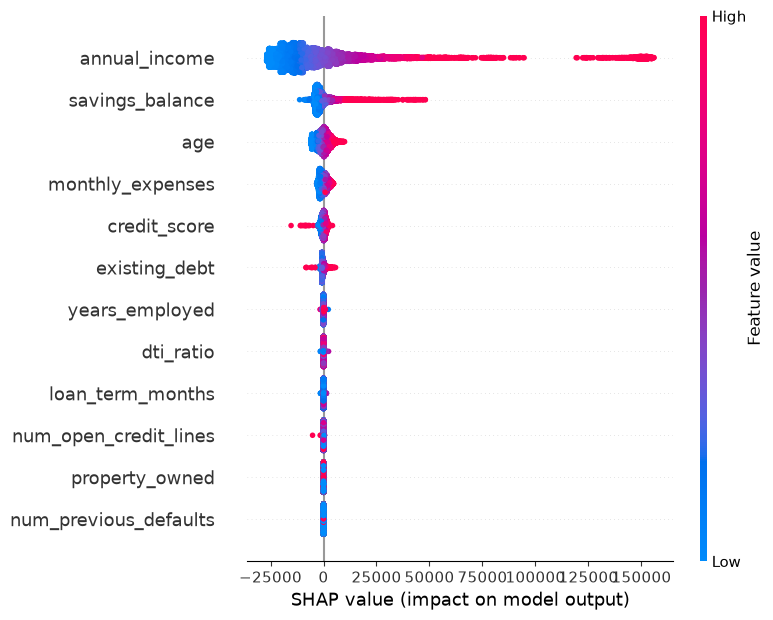

In [37]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X)

In [38]:
# CV strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# run CV
scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=cv,
    scoring="r2"
)

print("R2 scores per fold:", scores)
print("Mean R2:", scores.mean())
print("Std deviation:", scores.std())

R2 scores per fold: [0.99773618 0.99805704 0.99825282 0.99864276 0.99761556]
Mean R2: 0.9980608724680705
Std deviation: 0.00036855939265960163


In [39]:
test_pred = xgb_model.predict(X_test)

print("FINAL TEST R2:", r2_score(y_test, test_pred))

FINAL TEST R2: 0.9985205188069706


In [40]:
joblib.dump(xgb_model, "loan_amount_xgb.pkl")

print("Model saved.")

Model saved.


In [41]:
df5

,age,years_employed,annual_income,credit_score,dti_ratio,existing_debt,monthly_expenses,num_dependents,savings_balance,num_open_credit_lines,num_previous_defaults,property_owned,loan_term_months,market_rate,recommended_loan_amount,loan_purpose,employment_type
0,44,21,111847.46,626,0.3202,0.00,5482.05,2,128214.10,7,0,1,120,6.978,73744.17,3,2
1,38,15,44789.71,637,0.2477,10795.74,1183.80,0,11082.77,3,0,0,60,6.478,28612.28,5,2
2,46,24,120535.77,624,0.2443,34350.27,4304.42,3,50514.25,6,0,1,84,7.248,71414.88,3,3
3,55,36,26826.55,662,0.2992,8484.04,824.15,1,6641.62,0,0,0,48,5.904,26179.55,0,0
4,37,12,101526.65,618,0.1400,0.00,3720.98,1,66202.58,5,0,1,48,6.570,59251.02,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,30,5,2190158.61,673,0.3115,14232.28,2370.82,2,1314683.18,6,0,0,36,7.919,200000.00,6,2
14996,52,34,118695.93,647,0.2829,39929.73,6318.58,2,406107.74,5,0,1,84,7.753,113274.33,0,2
14997,53,28,60991.10,624,0.3128,15354.63,2564.11,0,39397.34,3,0,0,24,6.572,44181.93,5,3
14998,31,1,22225.90,602,0.2697,5513.37,585.34,2,4027.60,8,1,1,24,6.089,14573.65,2,2


In [45]:
calc_ratio = df5['existing_debt'] / df5['annual_income']
print((calc_ratio - df5['dti_ratio']).describe())

count    15000.000000
mean        -0.034672
std          0.099796
min         -0.505000
25%         -0.037127
50%         -0.006699
75%          0.022768
max          0.079496
dtype: float64


In [46]:
corr = (
    df5['existing_debt'] / df5['annual_income']
).corr(df5['dti_ratio'])

print(corr)

0.37842898875255004


In [44]:
X = df5.drop(columns=['recommended_loan_amount', 'dti_ratio'])
y = df5['dti_ratio'] 

# Split 1: 70-30 (test, validation)
X_train_70, X_test_val, y_train_70, y_test_val = train_test_split(
    X, y, test_size=0.30, random_state=42
)
# Step 2: split temp into 50-50 => 15% test, 15% validation
X_test, X_val, y_test, y_val = train_test_split(
    X_test_val, y_test_val, test_size=0.50, random_state=42
)
# Pipeline 1
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
linear_pipeline.fit(X_train_70, y_train_70)
y_val_pred_linear_pipeline = linear_pipeline.predict(X_val)
# Pipeline 2
rf_model = RandomForestRegressor(random_state=42)
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
rf_model.fit(X_train_70, y_train_70)
xgb_model.fit(X_train_70, y_train_70)
pred_rf = rf_model.predict(X_val)
pred_xgb = xgb_model.predict(X_val)
results = pd.DataFrame({
    "Model": ["Linear", "Random Forest", "XGBoost"],
    "R2": [
        r2_score(y_val, y_val_pred_linear_pipeline),
        r2_score(y_val, pred_rf),
        r2_score(y_val, pred_xgb)
    ],
    "MAE": [
        mean_absolute_error(y_val, y_val_pred_linear_pipeline),
        mean_absolute_error(y_val, pred_rf),
        mean_absolute_error(y_val, pred_xgb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_val, y_val_pred_linear_pipeline)),
        np.sqrt(mean_squared_error(y_val, pred_rf)),
        np.sqrt(mean_squared_error(y_val, pred_xgb))
    ]
})

results = results.sort_values("R2", ascending=False)
results

,Model,R2,MAE,RMSE
2,XGBoost,0.629343,0.025121,0.032654
1,Random Forest,0.616480,0.025463,0.033216
0,Linear,0.280576,0.036204,0.045493
